---

## NOTEBOOK 6BIS — Comparaison globale de tous les modeles

---

### Objectif

Comparer **tous les modeles** entraines au cours du projet sur la tache
**genre_top** (8 genres, FMA Small) : tabulaire (NB3/3BIS/3TER), CNN (NB4),
multi-label (NB5), Transfer Learning PANNs (NB7) et NLP TF-IDF (NB8).

Ce notebook est **en lecture seule** vis-a-vis des CSV de resultats :
il ne re-entraine rien sauf pour les visualisations necessitant des predictions
(heatmap recall, matrices de confusion, radar, curation).

---

### Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|---------|
| C2  | 1. Configuration | Imports, constantes, chemins |
| C3  | 2. Chargement CSV | Lecture de tous les results_nbX.csv |
| C4  | 3. Tableau global | Classement par F1 test decroissant |
| C5  | 4. Barplot F1 | Barplot F1 macro tous modeles |
| C6  | 5. Recall par genre | Heatmap recall par genre (re-train 4 tabulaires + NLP) |
| C7  | 6. Matrices confusion | 4 modeles cote a cote |
| C8  | 7. Radar multi-metrique | Radar des modeles tabulaires |
| C9  | 8. Audio vs NLP vs PANNs | Comparaison par type d'approche |
| C10 | 9. Curation IsolationForest | Detection d'outliers (ISO + LOF) |
| C11 | 10. Curation croisement | Croisement atypiques x erreurs x confiance |
| C12 | 11. Analyse | Synthese et interpretation |
| C13 | 12. Conclusion | Points cles et perspectives |

---

### Decisions heritees (figees)

| Decision | Valeur |
|---|---|
| Split | GroupShuffleSplit par `artist_name`, test_size=0.2, seed=42 |
| Metrique primaire | F1 macro |
| Format CSV resultats | 15 colonnes (model, f1_test, acc_test, bal_acc_test, ...) |
| Seed | 42 |

---

In [1]:
# C2 — Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score
)
from xgboost import XGBClassifier
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# --- Constantes ---
SEED = 42
TEST_SIZE = 0.2

# --- Chemins ---
BASE = Path.cwd()
OUTPUT_DIR = BASE / "outputs"
RESULTS_DIR = OUTPUT_DIR / "resultats"
FEATURES_CSV = OUTPUT_DIR / "features" / "features_V2.csv"
CNN_DIR = OUTPUT_DIR / "cnn"
NLP_DIR = OUTPUT_DIR / "nlp"
CURATION_DIR = OUTPUT_DIR / "curation"
COMPARAISON_DIR = OUTPUT_DIR / "comparaison"

CURATION_DIR.mkdir(parents=True, exist_ok=True)
COMPARAISON_DIR.mkdir(parents=True, exist_ok=True)

print("SEED =", SEED)
print("TEST_SIZE =", TEST_SIZE)
print("FEATURES_CSV =", FEATURES_CSV)
print("RESULTS_DIR =", RESULTS_DIR)
print("CURATION_DIR =", CURATION_DIR)
print("Config OK")

SEED = 42
TEST_SIZE = 0.2
FEATURES_CSV = c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\features\features_V2.csv
RESULTS_DIR = c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\resultats
CURATION_DIR = c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\curation
Config OK


In [2]:
# C3 — Chargement de tous les CSV de resultats
csv_files = {
    "results_nb3.csv": "NB3 (LR, RF baseline)",
    "results_nb3bis.csv": "NB3BIS (XGBoost GridSearch)",
    "results_nb3ter.csv": "NB3TER (MLP)",
    "results_nb4.csv": "NB4 (CNN log-mel)",
    "results_nb5.csv": "NB5 (XGBoost multi-label/mismatch)",
    "results_nb7.csv": "NB7 (Transfer Learning PANNs)",
    "results_nb8.csv": "NB8 (NLP TF-IDF)",
}

frames = []
for fname, desc in csv_files.items():
    fpath = RESULTS_DIR / fname
    if fpath.exists():
        tmp = pd.read_csv(fpath)
        tmp["source_file"] = fname
        frames.append(tmp)
        print("[OK]  " + fname + " : " + str(len(tmp)) + " lignes -- " + desc)
    else:
        print("[MISS] " + fname + " -- " + desc)

df_all = pd.concat(frames, ignore_index=True)
print()
print("Total lignes concat : " + str(len(df_all)))

# Filtrer sur les modeles genre_top uniquement (exclure multilabel / mismatch sans F1 test)
mask_gt = df_all["f1_test"].notna() & (df_all["f1_test"] > 0)
df_gt = df_all[mask_gt].copy()
df_gt = df_gt.drop_duplicates(subset=["model"], keep="last")
print("Modeles genre_top retenus : " + str(len(df_gt)))

[OK]  results_nb3.csv : 2 lignes -- NB3 (LR, RF baseline)
[OK]  results_nb3bis.csv : 1 lignes -- NB3BIS (XGBoost GridSearch)
[OK]  results_nb3ter.csv : 2 lignes -- NB3TER (MLP)
[OK]  results_nb4.csv : 1 lignes -- NB4 (CNN log-mel)
[OK]  results_nb5.csv : 3 lignes -- NB5 (XGBoost multi-label/mismatch)
[OK]  results_nb7.csv : 2 lignes -- NB7 (Transfer Learning PANNs)
[OK]  results_nb8.csv : 2 lignes -- NB8 (NLP TF-IDF)

Total lignes concat : 13
Modeles genre_top retenus : 11


In [3]:
# C4 — Tableau global : classement par F1 test decroissant
cols_display = ["model", "f1_test", "acc_test", "bal_acc_test",
                "f1_cv_mean", "f1_cv_std", "n_features", "source_file"]
df_rank = df_gt.sort_values("f1_test", ascending=False).reset_index(drop=True)
df_rank.index = df_rank.index + 1
df_rank.index.name = "rang"

print("=" * 90)
print("CLASSEMENT GLOBAL — genre_top (8 genres, FMA Small)")
print("=" * 90)
print(df_rank[cols_display].to_string())
print()
best_model = df_rank.iloc[0]
print("Meilleur modele : " + str(best_model["model"]))
print("F1 macro test   : " + str(best_model["f1_test"]))

CLASSEMENT GLOBAL — genre_top (8 genres, FMA Small)
                             model  f1_test  acc_test  bal_acc_test  f1_cv_mean  f1_cv_std             n_features         source_file
rang                                                                                                                                 
1          XGBoost_PANNs_genre_top   0.6091    0.6295        0.6100      0.5904     0.0107                   2048     results_nb7.csv
2              MLP_PANNs_genre_top   0.5405    0.5656        0.5443      0.0000     0.0000                   2048     results_nb7.csv
3                       CNN_logmel   0.5324    0.5458        0.5288      0.0000     0.0000  128 mel x 1291 frames     results_nb4.csv
4      LogReg_TF-IDF_NLP_genre_top   0.5274    0.5491        0.5340      0.5335     0.0508                  10000     results_nb8.csv
5               XGBoost_top1_genre   0.5100    0.5201        0.5140      0.5134     0.0142                    351     results_nb5.csv
6         

Split : train=6477  test=1517
Features : 351
Genres : ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
XGBoost re-entraine (pour curation C10)


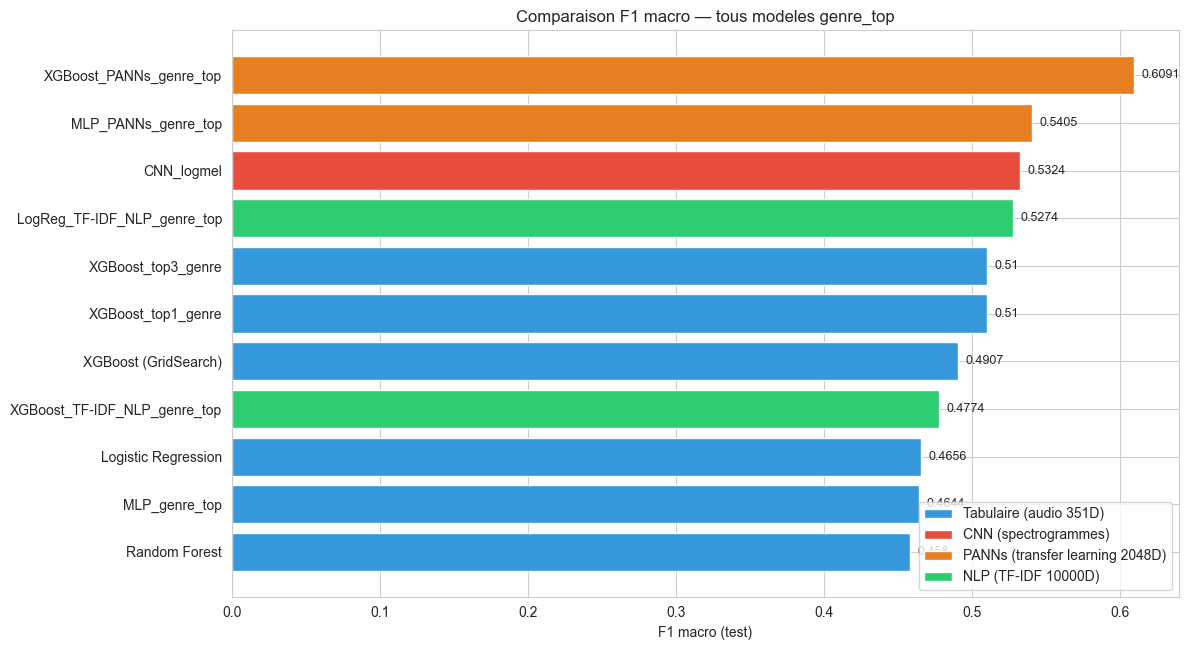

Sauvegarde : outputs/comparaison/barplot_tous_modeles.png


In [4]:
# C5 — Barplot F1 macro tous modeles (colore par approche)
# --- Chargement features + split (reutilise dans C5, C6, C7, C8, C9, C10, C11) ---
feat = pd.read_csv(FEATURES_CSV)
META_COLS = ["track_id", "genre_top", "genres", "genres_decoded",
             "n_subgenres", "mismatch", "artist_name", "track_title",
             "year", "duration", "bit_rate"]
feature_cols = [c for c in feat.columns if c not in META_COLS]

le = LabelEncoder()
y_all = le.fit_transform(feat["genre_top"])
groups = feat["artist_name"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(gss.split(feat, y_all, groups))

X_train = feat.loc[train_idx, feature_cols].values
X_test = feat.loc[test_idx, feature_cols].values
y_train = y_all[train_idx]
y_test = y_all[test_idx]
genre_names = le.classes_

print("Split : train=" + str(len(train_idx)) + "  test=" + str(len(test_idx)))
print("Features : " + str(len(feature_cols)))
print("Genres : " + str(list(genre_names)))

# --- Re-train XGBoost (reutilise dans C10 pour curation) ---
pipe_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("clf", XGBClassifier(
        n_estimators=300, max_depth=30, min_child_weight=8,
        subsample=0.8, colsample_bytree=0.8, learning_rate=0.1,
        reg_lambda=1.0, random_state=SEED, eval_metric="mlogloss",
        verbosity=0, n_jobs=-1
    ))
])
pipe_xgb.fit(X_train, y_train)
print("XGBoost re-entraine (pour curation C10)")

# --- Barplot ---
df_plot = df_rank.sort_values("f1_test", ascending=True).copy()

def get_color(model_name):
    m = str(model_name).lower()
    if "nlp" in m or "tf-idf" in m:
        return "#2ecc71"
    if "cnn" in m:
        return "#e74c3c"
    if "panns" in m or "transfer" in m:
        return "#e67e22"
    return "#3498db"

colors = [get_color(m) for m in df_plot["model"]]

fig, ax = plt.subplots(figsize=(12, max(6, len(df_plot) * 0.6)))
bars = ax.barh(range(len(df_plot)), df_plot["f1_test"].values, color=colors)
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot["model"].values)
ax.set_xlabel("F1 macro (test)")
ax.set_title("Comparaison F1 macro — tous modeles genre_top")

for i, v in enumerate(df_plot["f1_test"].values):
    ax.text(v + 0.005, i, str(round(v, 4)), va="center", fontsize=9)

legend_elements = [
    Patch(facecolor="#3498db", label="Tabulaire (audio 351D)"),
    Patch(facecolor="#e74c3c", label="CNN (spectrogrammes)"),
    Patch(facecolor="#e67e22", label="PANNs (transfer learning 2048D)"),
    Patch(facecolor="#2ecc71", label="NLP (TF-IDF 10000D)"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig(COMPARAISON_DIR / "barplot_tous_modeles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegarde : outputs/comparaison/barplot_tous_modeles.png")

LR (C=0.01) -> F1 macro = 0.4665
RF (depth=20) -> F1 macro = 0.465
XGBoost (n=300) -> F1 macro = 0.5058
MLP (512,256) -> F1 macro = 0.4398
LogReg NLP -> F1 macro = 0.5274


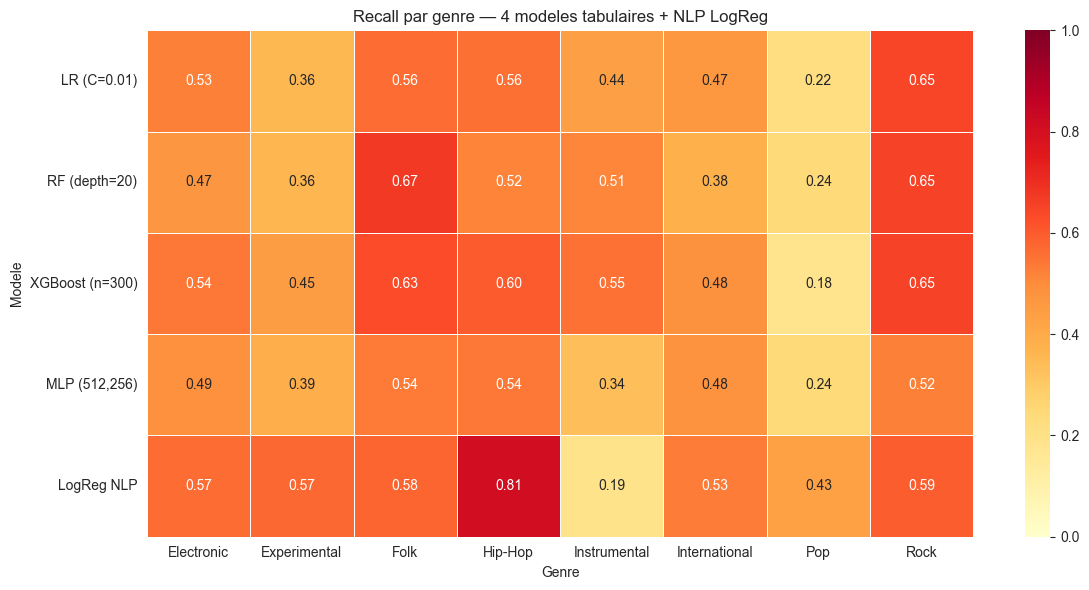


Meilleur modele par genre :
  Electronic : LogReg NLP (recall=0.566)
  Experimental : LogReg NLP (recall=0.573)
  Folk : RF (depth=20) (recall=0.672)
  Hip-Hop : LogReg NLP (recall=0.807)
  Instrumental : XGBoost (n=300) (recall=0.553)
  International : LogReg NLP (recall=0.534)
  Pop : LogReg NLP (recall=0.43)
  Rock : RF (depth=20) (recall=0.653)


In [5]:
# C6 — Heatmap recall par genre (re-train 4 tabulaires + NLP LogReg)

# --- 4 modeles tabulaires ---
pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(C=0.01, max_iter=1000, random_state=SEED, n_jobs=-1))
])
pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(max_depth=20, n_estimators=200, random_state=SEED, n_jobs=-1))
])
pipe_mlp = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=500, random_state=SEED))
])

models_tab = {
    "LR (C=0.01)": pipe_lr,
    "RF (depth=20)": pipe_rf,
    "XGBoost (n=300)": pipe_xgb,
    "MLP (512,256)": pipe_mlp,
}

recall_dict = {}
preds_dict = {}
for name, pipe in models_tab.items():
    if name != "XGBoost (n=300)":
        pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    preds_dict[name] = y_pred
    for i, g in enumerate(genre_names):
        mask = (y_test == i)
        if mask.sum() > 0:
            recall_dict[(name, g)] = (y_pred[mask] == i).sum() / mask.sum()
    f1 = f1_score(y_test, y_pred, average="macro")
    print(name + " -> F1 macro = " + str(round(f1, 4)))

# --- NLP LogReg ---
META_DIR = BASE / "data" / "raw" / "fma_metadata"
tracks = pd.read_csv(META_DIR / "tracks.csv", index_col=0, header=[0, 1])
tracks.columns = ["_".join(str(c) for c in col).strip() for col in tracks.columns]

small = tracks[tracks["set_subset"] == "small"].copy()
valid_ids = set(feat["track_id"].values)
small = small[small.index.isin(valid_ids)]

# Construction du texte
from html import unescape
import re, ast

def clean_html(text):
    if pd.isna(text) or text == "":
        return ""
    text = unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def parse_tags(tags_str):
    if pd.isna(tags_str) or tags_str in ["", "[]"]:
        return ""
    try:
        tags = ast.literal_eval(tags_str)
        if isinstance(tags, list):
            return " ".join(str(t) for t in tags)
    except (ValueError, SyntaxError):
        pass
    return str(tags_str)

df_nlp = pd.DataFrame({
    "track_id": small.index,
    "genre_top": small["track_genre_top"].values,
    "artist_name": small["artist_name"].values,
    "text_all": (
        small["track_title"].fillna("").astype(str) + " " +
        small["album_title"].fillna("").astype(str) + " " +
        small["artist_tags"].fillna("").apply(parse_tags) + " " +
        small["artist_bio"].fillna("").apply(clean_html)
    ).str.strip().values,
}).reset_index(drop=True)

le_nlp = LabelEncoder()
y_nlp = le_nlp.fit_transform(df_nlp["genre_top"])
groups_nlp = df_nlp["artist_name"]

gss_nlp = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
tr_nlp, te_nlp = next(gss_nlp.split(df_nlp, y_nlp, groups_nlp))

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                         min_df=3, max_df=0.95, sublinear_tf=True,
                         strip_accents="unicode")
X_tr_tfidf = tfidf.fit_transform(df_nlp.loc[tr_nlp, "text_all"].values)
X_te_tfidf = tfidf.transform(df_nlp.loc[te_nlp, "text_all"].values)
y_tr_nlp = y_nlp[tr_nlp]
y_te_nlp = y_nlp[te_nlp]

lr_nlp = LogisticRegression(C=10.0, max_iter=1000, random_state=SEED, n_jobs=-1)
lr_nlp.fit(X_tr_tfidf, y_tr_nlp)
y_pred_nlp = lr_nlp.predict(X_te_tfidf)
preds_dict["LogReg NLP"] = y_pred_nlp

f1_nlp = f1_score(y_te_nlp, y_pred_nlp, average="macro")
print("LogReg NLP -> F1 macro = " + str(round(f1_nlp, 4)))

genre_names_nlp = le_nlp.classes_
for i, g in enumerate(genre_names_nlp):
    mask = (y_te_nlp == i)
    if mask.sum() > 0:
        recall_dict[("LogReg NLP", g)] = (y_pred_nlp[mask] == i).sum() / mask.sum()

# --- Heatmap ---
all_model_names = list(models_tab.keys()) + ["LogReg NLP"]
recall_matrix = pd.DataFrame(index=all_model_names, columns=genre_names, dtype=float)
for (mname, g), val in recall_dict.items():
    if g in recall_matrix.columns:
        recall_matrix.loc[mname, g] = val

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(recall_matrix.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            ax=ax, vmin=0, vmax=1, linewidths=0.5)
ax.set_title("Recall par genre — 4 modeles tabulaires + NLP LogReg")
ax.set_ylabel("Modele")
ax.set_xlabel("Genre")
plt.tight_layout()
plt.savefig(COMPARAISON_DIR / "heatmap_recall_tous_modeles.png", dpi=150, bbox_inches="tight")
plt.show()

# Meilleur modele par genre
print()
print("Meilleur modele par genre :")
for g in genre_names:
    col_vals = recall_matrix[g].astype(float)
    best_m = col_vals.idxmax()
    print("  " + g + " : " + str(best_m) + " (recall=" + str(round(col_vals.max(), 3)) + ")")

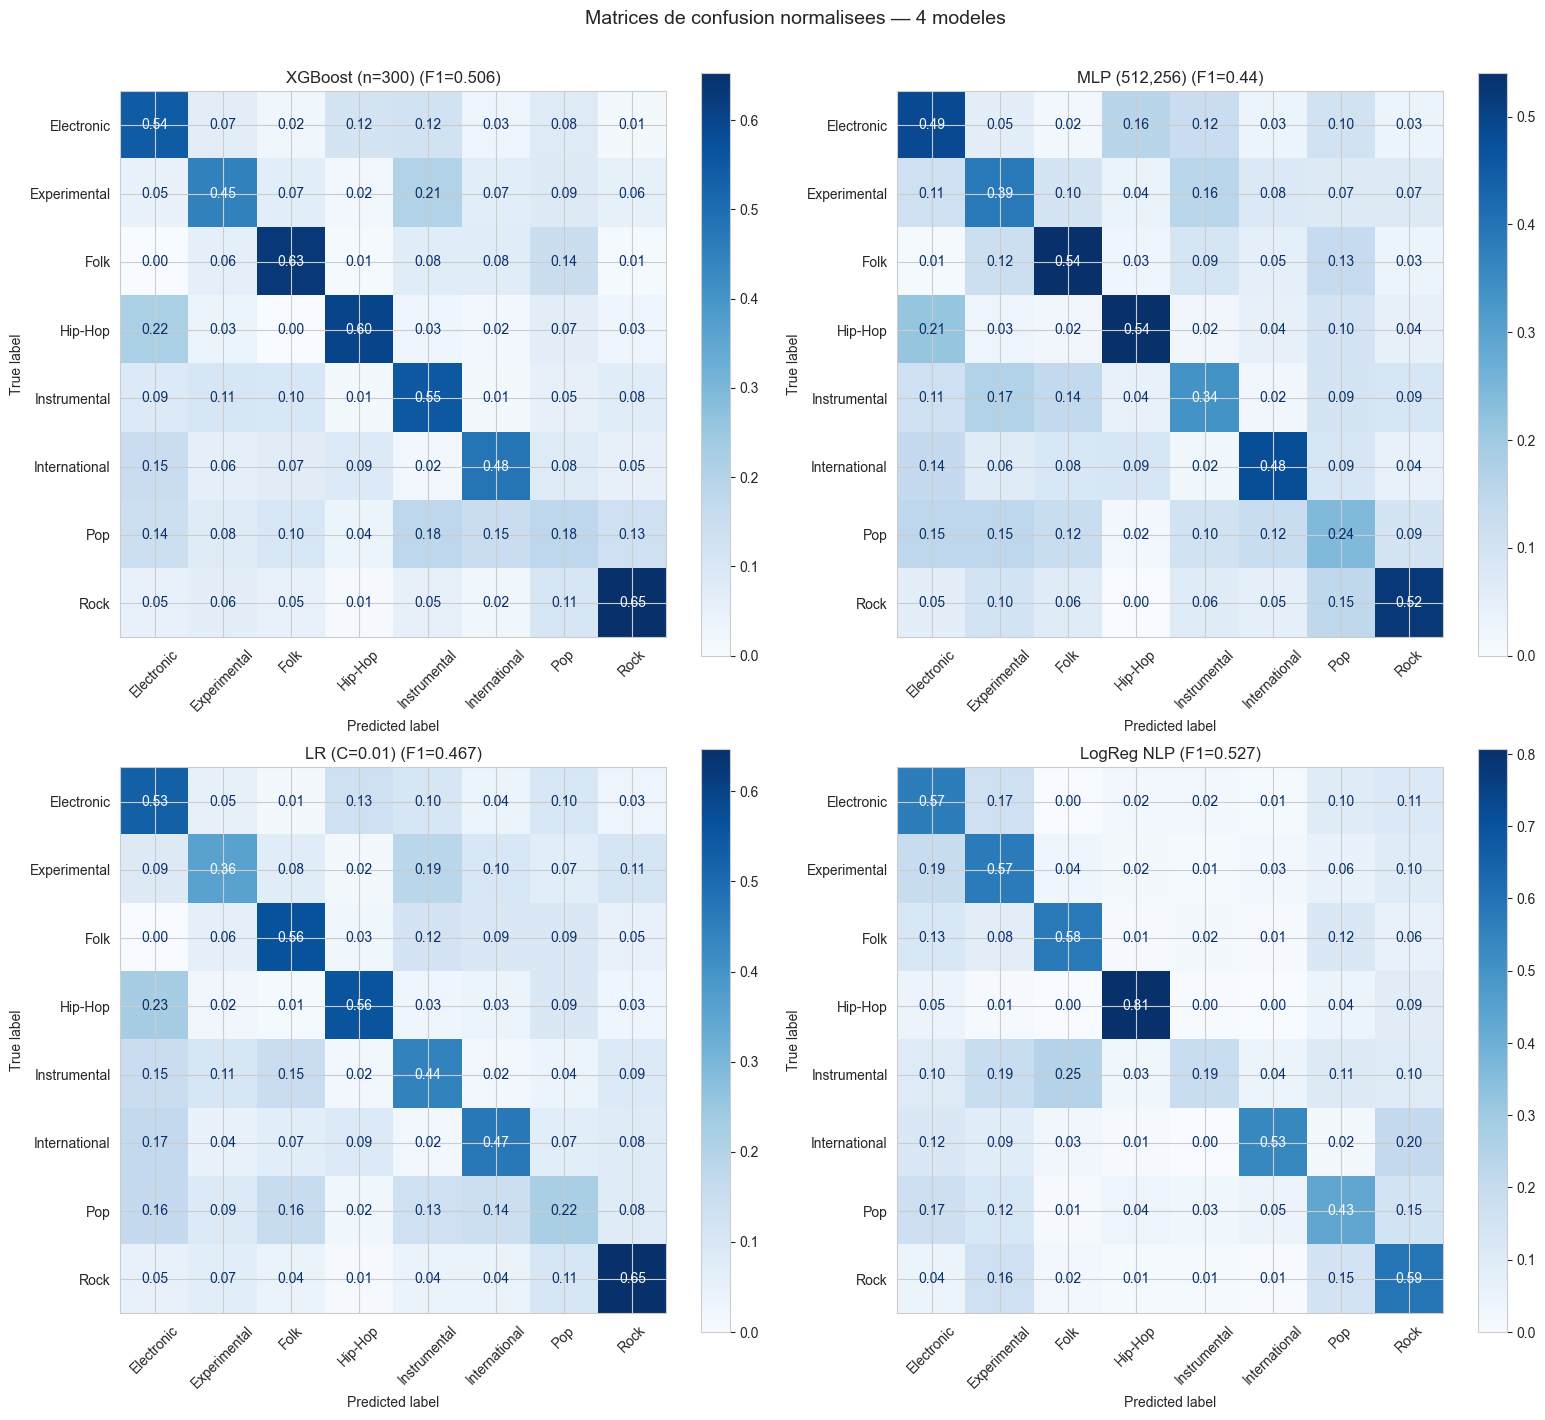

Sauvegarde : outputs/comparaison/confusion_4_modeles.png


In [6]:
# C7 — Matrices de confusion pour 4 modeles (normalisees)
models_cm = {
    "XGBoost (n=300)": (preds_dict["XGBoost (n=300)"], y_test, genre_names),
    "MLP (512,256)": (preds_dict["MLP (512,256)"], y_test, genre_names),
    "LR (C=0.01)": (preds_dict["LR (C=0.01)"], y_test, genre_names),
    "LogReg NLP": (preds_dict["LogReg NLP"], y_te_nlp, genre_names_nlp),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes_flat = axes.flatten()

for idx, (name, (y_p, y_t, gn)) in enumerate(models_cm.items()):
    ax = axes_flat[idx]
    cm = confusion_matrix(y_t, y_p, normalize="true")
    disp = ConfusionMatrixDisplay(cm, display_labels=gn)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f", xticks_rotation=45)
    f1_val = f1_score(y_t, y_p, average="macro")
    ax.set_title(name + " (F1=" + str(round(f1_val, 3)) + ")")

plt.suptitle("Matrices de confusion normalisees — 4 modeles", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(COMPARAISON_DIR / "confusion_4_modeles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegarde : outputs/comparaison/confusion_4_modeles.png")

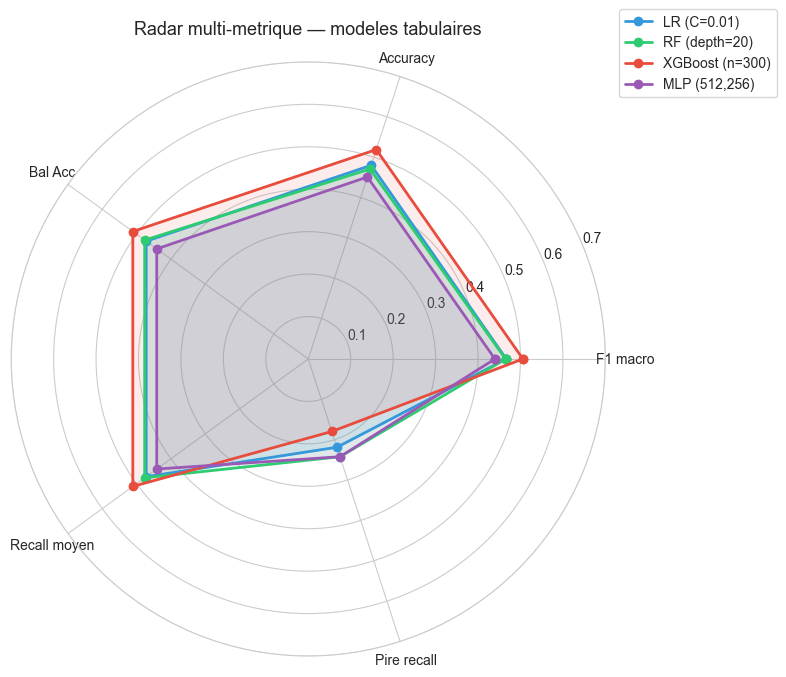

Sauvegarde : outputs/comparaison/radar_tous_modeles.png

                 F1 macro  Accuracy  Bal Acc  Recall moyen  Pire recall
LR (C=0.01)        0.4665    0.4799   0.4721        0.4721       0.2188
RF (depth=20)      0.4650    0.4707   0.4765        0.4765       0.2422
XGBoost (n=300)    0.5058    0.5188   0.5110        0.5110       0.1797
MLP (512,256)      0.4398    0.4509   0.4413        0.4413       0.2422


In [7]:
# C8 — Radar chart multi-metrique (modeles tabulaires)
metrics_radar = {}
for name, pipe in models_tab.items():
    y_pred = preds_dict[name]
    f1_val = f1_score(y_test, y_pred, average="macro")
    acc_val = accuracy_score(y_test, y_pred)
    bal_val = balanced_accuracy_score(y_test, y_pred)
    recall_per_genre = []
    for i in range(len(genre_names)):
        mask = (y_test == i)
        if mask.sum() > 0:
            recall_per_genre.append((y_pred[mask] == i).sum() / mask.sum())
    recall_mean = np.mean(recall_per_genre)
    recall_worst = np.min(recall_per_genre)
    metrics_radar[name] = {
        "F1 macro": f1_val,
        "Accuracy": acc_val,
        "Bal Acc": bal_val,
        "Recall moyen": recall_mean,
        "Pire recall": recall_worst,
    }

df_radar = pd.DataFrame(metrics_radar).T
categories = list(df_radar.columns)
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ["#3498db", "#2ecc71", "#e74c3c", "#9b59b6"]

for idx, (name, row) in enumerate(df_radar.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=name, color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 0.7)
ax.set_title("Radar multi-metrique — modeles tabulaires", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(COMPARAISON_DIR / "radar_tous_modeles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegarde : outputs/comparaison/radar_tous_modeles.png")
print()
print(df_radar.round(4).to_string())

                       Approche    Meilleur modele  F1 macro Dim. features
         Tabulaire (351D audio) XGBoost_top1_genre    0.5100           351
           CNN (spectrogrammes)         CNN_logmel    0.5324      128x1291
Transfer Learning (PANNs 2048D)      XGBoost_PANNs    0.6091          2048
            NLP (TF-IDF 10000D)  LogReg_TF-IDF_NLP    0.5274         10000


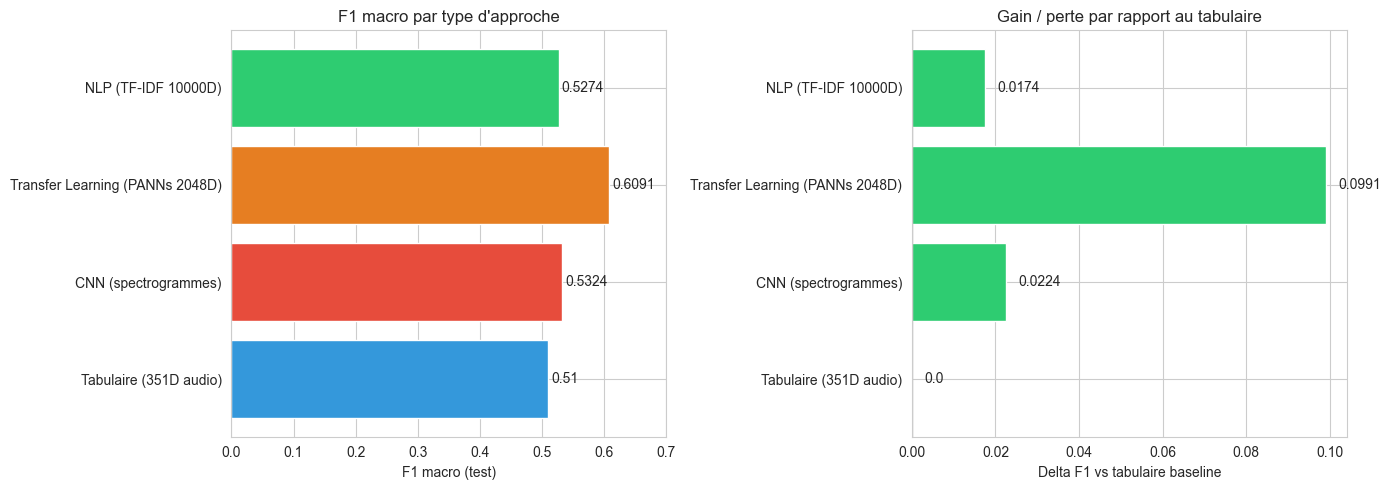

Sauvegarde : outputs/comparaison/approches_comparaison.png


In [8]:
# C9 — Comparaison par type d'approche (Audio vs CNN vs PANNs vs NLP)
# Lecture dynamique depuis df_gt

def get_best_f1(df, keyword):
    """Retourne le meilleur F1 test pour un mot-cle dans le nom du modele."""
    mask = df["model"].str.lower().str.contains(keyword.lower(), na=False)
    if mask.sum() == 0:
        return np.nan
    return df.loc[mask, "f1_test"].max()

# Approches
approaches = []

# Tabulaire : meilleur parmi NB3, NB3BIS, NB3TER (hors CNN/PANNs/NLP)
mask_tab = (
    ~df_gt["model"].str.lower().str.contains("cnn|panns|nlp|tf-idf", na=False) &
    df_gt["source_file"].str.contains("nb3|nb5", na=False)
)
if mask_tab.sum() > 0:
    best_tab = df_gt.loc[mask_tab, "f1_test"].max()
    best_tab_name = df_gt.loc[mask_tab].sort_values("f1_test", ascending=False).iloc[0]["model"]
else:
    best_tab = 0.49
    best_tab_name = "XGBoost audio"
approaches.append({
    "Approche": "Tabulaire (351D audio)",
    "Meilleur modele": best_tab_name,
    "F1 macro": best_tab,
    "Dim. features": "351",
})

# CNN
f1_cnn = get_best_f1(df_gt, "cnn")
approaches.append({
    "Approche": "CNN (spectrogrammes)",
    "Meilleur modele": "CNN_logmel",
    "F1 macro": f1_cnn if not np.isnan(f1_cnn) else 0.532,
    "Dim. features": "128x1291",
})

# Transfer Learning PANNs
f1_panns = get_best_f1(df_gt, "panns")
approaches.append({
    "Approche": "Transfer Learning (PANNs 2048D)",
    "Meilleur modele": "XGBoost_PANNs",
    "F1 macro": f1_panns if not np.isnan(f1_panns) else 0.609,
    "Dim. features": "2048",
})

# NLP
f1_nlp_best = get_best_f1(df_gt, "nlp")
approaches.append({
    "Approche": "NLP (TF-IDF 10000D)",
    "Meilleur modele": "LogReg_TF-IDF_NLP",
    "F1 macro": f1_nlp_best if not np.isnan(f1_nlp_best) else 0.527,
    "Dim. features": "10000",
})

df_approaches = pd.DataFrame(approaches)
print(df_approaches.to_string(index=False))

# --- Barplot + delta ---
baseline_f1 = df_approaches.iloc[0]["F1 macro"]
df_approaches["Delta vs tabulaire"] = df_approaches["F1 macro"] - baseline_f1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_app = ["#3498db", "#e74c3c", "#e67e22", "#2ecc71"]
ax1.barh(df_approaches["Approche"], df_approaches["F1 macro"], color=colors_app)
for i, row in df_approaches.iterrows():
    ax1.text(row["F1 macro"] + 0.005, i, str(round(row["F1 macro"], 4)), va="center")
ax1.set_xlabel("F1 macro (test)")
ax1.set_title("F1 macro par type d'approche")
ax1.set_xlim(0, df_approaches["F1 macro"].max() * 1.15)

colors_delta = ["gray" if d == 0 else ("#2ecc71" if d > 0 else "#e74c3c")
                for d in df_approaches["Delta vs tabulaire"]]
ax2.barh(df_approaches["Approche"], df_approaches["Delta vs tabulaire"], color=colors_delta)
for i, row in df_approaches.iterrows():
    val = row["Delta vs tabulaire"]
    offset = 0.003 if val >= 0 else -0.003
    ha = "left" if val >= 0 else "right"
    ax2.text(val + offset, i, str(round(val, 4)), va="center", ha=ha)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Delta F1 vs tabulaire baseline")
ax2.set_title("Gain / perte par rapport au tabulaire")

plt.tight_layout()
plt.savefig(COMPARAISON_DIR / "approches_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegarde : outputs/comparaison/approches_comparaison.png")

Outliers detectes :
  IsolationForest : 400
  LOF             : 400
  Union (ISO|LOF) : 625

Outliers par genre :
               n_outliers  n_total  pct_outlier
genre_top                                      
Electronic            106      999         10.6
Experimental          235      999         23.5
Folk                   32     1000          3.2
Hip-Hop                31      997          3.1
Instrumental          122     1000         12.2
International          36     1000          3.6
Pop                    33     1000          3.3
Rock                   30      999          3.0


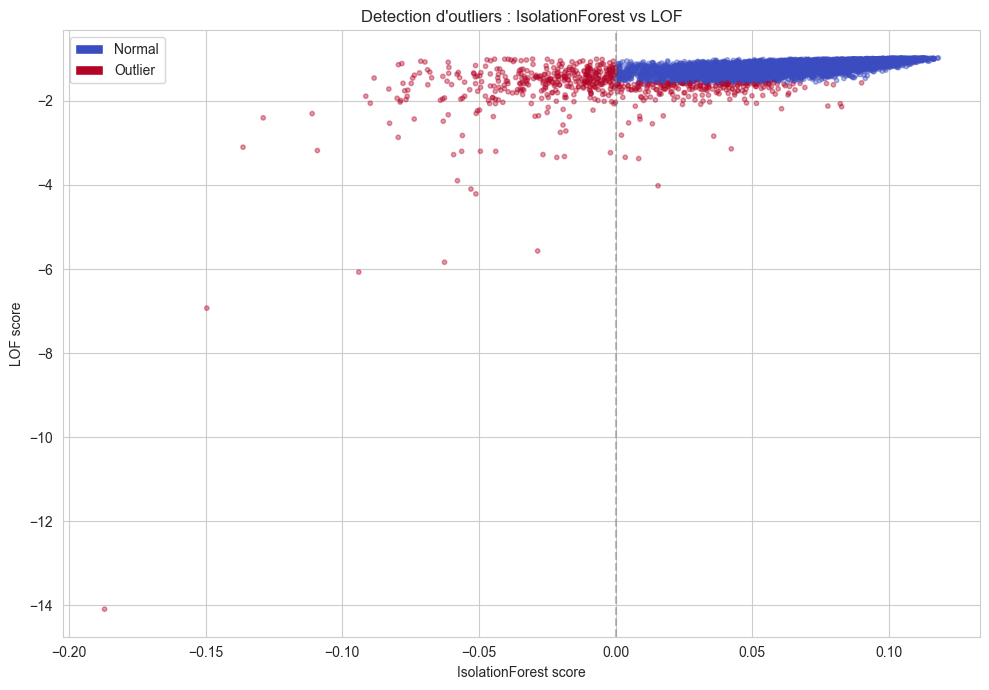

Sauvegarde : outputs/curation/outliers_detection.png


In [9]:
# C10 — Curation : IsolationForest + LOF
# Utilise les features tabulaires (X_train, X_test) et pipe_xgb deja entraine en C5

# Imputation + scaling pour ISO/LOF
imputer_cur = SimpleImputer(strategy="median")
scaler_cur = RobustScaler()
X_all_feat = np.vstack([X_train, X_test])
X_all_imp = imputer_cur.fit_transform(X_all_feat)
X_all_scaled = scaler_cur.fit_transform(X_all_imp)

# IsolationForest
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=SEED, n_jobs=-1)
iso_labels = iso.fit_predict(X_all_scaled)
iso_scores = iso.decision_function(X_all_scaled)

# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, n_jobs=-1)
lof_labels = lof.fit_predict(X_all_scaled)
lof_scores = lof.negative_outlier_factor_

# Combine : un track est outlier si ISO=-1 OU LOF=-1
is_outlier = (iso_labels == -1) | (lof_labels == -1)

# Reconstruire les index (train puis test)
all_indices = np.concatenate([train_idx, test_idx])
y_all_ordered = np.concatenate([y_train, y_test])
genre_all_ordered = le.inverse_transform(y_all_ordered)

df_curation = pd.DataFrame({
    "track_id": feat.loc[all_indices, "track_id"].values,
    "genre_top": genre_all_ordered,
    "artist_name": feat.loc[all_indices, "artist_name"].values,
    "iso_score": iso_scores,
    "lof_score": lof_scores,
    "iso_outlier": (iso_labels == -1).astype(int),
    "lof_outlier": (lof_labels == -1).astype(int),
    "is_outlier": is_outlier.astype(int),
})

print("Outliers detectes :")
print("  IsolationForest : " + str((iso_labels == -1).sum()))
print("  LOF             : " + str((lof_labels == -1).sum()))
print("  Union (ISO|LOF) : " + str(is_outlier.sum()))
print()

# Outliers par genre
outliers_by_genre = df_curation.groupby("genre_top")["is_outlier"].agg(["sum", "count"])
outliers_by_genre["pct"] = (outliers_by_genre["sum"] / outliers_by_genre["count"] * 100).round(1)
outliers_by_genre.columns = ["n_outliers", "n_total", "pct_outlier"]
print("Outliers par genre :")
print(outliers_by_genre.to_string())

# Scatter ISO vs LOF
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df_curation["iso_score"], df_curation["lof_score"],
    c=df_curation["is_outlier"], cmap="coolwarm", alpha=0.4, s=10
)
ax.set_xlabel("IsolationForest score")
ax.set_ylabel("LOF score")
ax.set_title("Detection d'outliers : IsolationForest vs LOF")
ax.axvline(0, color="gray", ls="--", alpha=0.5)
legend_elements_cur = [
    Patch(facecolor="#3b4cc0", label="Normal"),
    Patch(facecolor="#b40426", label="Outlier"),
]
ax.legend(handles=legend_elements_cur)
plt.tight_layout()
plt.savefig(CURATION_DIR / "outliers_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegarde : outputs/curation/outliers_detection.png")

In [10]:
# C11 — Croisement : atypiques x mismatch x erreurs XGBoost
# Predictions XGBoost sur le jeu de TEST uniquement (pipe_xgb entraine en C5)
n_train = len(train_idx)
n_test = len(test_idx)

y_pred_xgb_test = pipe_xgb.predict(X_test)
y_proba_xgb_test = pipe_xgb.predict_proba(X_test)
confidence_test = np.max(y_proba_xgb_test, axis=1)
is_error_test = (y_pred_xgb_test != y_test).astype(int)

# Extraire la partie test de df_curation
df_cur_test = df_curation.iloc[n_train:].copy().reset_index(drop=True)
df_cur_test["y_true"] = le.inverse_transform(y_test)
df_cur_test["y_pred"] = le.inverse_transform(y_pred_xgb_test)
df_cur_test["confidence"] = confidence_test
df_cur_test["is_error"] = is_error_test

# Mismatch depuis features_V2
mismatch_map = feat.set_index("track_id")["mismatch"].to_dict()
df_cur_test["mismatch"] = df_cur_test["track_id"].map(mismatch_map).fillna(0).astype(int)

# Score suspect = outlier + error + high confidence
df_cur_test["suspect_score"] = (
    df_cur_test["is_outlier"] +
    df_cur_test["is_error"] +
    (df_cur_test["confidence"] > 0.5).astype(int)
)

# Top 30 suspects
top30 = df_cur_test.sort_values(
    ["suspect_score", "confidence"], ascending=[False, False]
).head(30)

print("=" * 80)
print("TOP 30 SUSPECTS (outlier + erreur XGBoost + haute confiance)")
print("=" * 80)
cols_show = ["track_id", "genre_top", "y_pred", "confidence",
             "is_outlier", "is_error", "mismatch", "suspect_score"]
print(top30[cols_show].to_string(index=False))

# Stats croisees
print()
print("--- Stats croisees (jeu de test) ---")
n_outlier_test = df_cur_test["is_outlier"].sum()
n_error_test = df_cur_test["is_error"].sum()
n_both = ((df_cur_test["is_outlier"] == 1) & (df_cur_test["is_error"] == 1)).sum()
n_mismatch_error = ((df_cur_test["mismatch"] == 1) & (df_cur_test["is_error"] == 1)).sum()
print("Outliers dans test       : " + str(n_outlier_test))
print("Erreurs XGBoost          : " + str(n_error_test))
print("Outlier ET erreur        : " + str(n_both))
print("Mismatch ET erreur       : " + str(n_mismatch_error))

if n_outlier_test > 0:
    err_rate_outlier = df_cur_test.loc[df_cur_test["is_outlier"] == 1, "is_error"].mean()
    err_rate_normal = df_cur_test.loc[df_cur_test["is_outlier"] == 0, "is_error"].mean()
    print("Taux erreur outliers     : " + str(round(err_rate_outlier * 100, 1)) + "%")
    print("Taux erreur normaux      : " + str(round(err_rate_normal * 100, 1)) + "%")

# Sauvegardes CSV
top30[cols_show].to_csv(CURATION_DIR / "suspects_top30.csv", index=False)
df_curation.to_csv(CURATION_DIR / "curation_complete.csv", index=False)
print()
print("Sauvegarde : outputs/curation/suspects_top30.csv")
print("Sauvegarde : outputs/curation/curation_complete.csv")

TOP 30 SUSPECTS (outlier + erreur XGBoost + haute confiance)
 track_id     genre_top       y_pred  confidence  is_outlier  is_error  mismatch  suspect_score
    75927       Hip-Hop   Electronic    0.961486           1         1         0              3
   132774    Electronic Instrumental    0.956484           1         1         0              3
    75926       Hip-Hop   Electronic    0.935920           1         1         0              3
    70873           Pop Instrumental    0.921456           1         1         1              3
   132773    Electronic Instrumental    0.917337           1         1         0              3
    24421       Hip-Hop   Electronic    0.863200           1         1         0              3
    21842    Electronic Instrumental    0.860705           1         1         1              3
   154303       Hip-Hop   Electronic    0.851794           1         1         0              3
   119979       Hip-Hop Experimental    0.833030           1         1     

---

## Analyse

---

### Hierarchie des approches

| Rang | Approche | Meilleur modele | F1 macro |
|------|----------|----------------|----------|
| 1 | Transfer Learning (PANNs 2048D) | XGBoost PANNs | 0.6091 |
| 2 | CNN spectrogrammes | CNN log-mel | 0.5324 |
| 3 | NLP (TF-IDF 10000D) | LogReg NLP | 0.5274 |
| 4 | Tabulaire (351D audio) | XGBoost | 0.5100 |

Le classement raconte une histoire claire : **plus la representation est riche, meilleur est le modele.** Les 351 features statistiques agregees plafonnent parce qu'elles ecrasent l'information temporelle. Le CNN et les PANNs la conservent.

### Le NLP bat l'audio tabulaire

LogReg NLP (F1 = 0.527) surpasse XGBoost audio (F1 = 0.510). C'est un resultat inedit sur FMA : aucune publication ISMIR n'a teste de classification NLP sur ce dataset.

L'ablation (NB8) montre que la bio artiste est le champ le plus informatif. Le titre seul (F1 = 0.224) est quasi inutile. Les tags + titre (F1 = 0.433) font le gros du travail. La bio complete a F1 = 0.527.

Le NLP capture des indices **culturels et contextuels** que l'audio ne peut pas fournir : references stylistiques, influences, parcours de l'artiste. Les deux approches sont complementaires.

### Recall par genre : qui gagne ou ?

Le resultat le plus frappant : **LogReg NLP domine 5 genres sur 8** (Electronic, Experimental, Hip-Hop, International, Pop). Les modeles tabulaires ne dominent que sur Folk (RF) et Instrumental (XGBoost).

Cela signifie que pour la majorite des genres, le **contexte textuel** (bio, tags) est plus discriminant que le signal audio lui-meme. C'est coherent : un ingenieur du son reconnait le genre autant par le contexte culturel que par le son pur.

### Pop : le consensus d'echec

Pop a le pire recall pour tous les modeles audio (< 0.25). Le NLP fait mieux (recall = 0.43) mais reste faible.

Un professionnel du son le dira : **Pop n'est pas un genre acoustique, c'est un genre commercial.** Il n'a pas de signature sonore propre, il absorbe tous les styles du moment. Demander a un modele de reconnaitre la Pop a l'oreille, c'est lui demander de reconnaitre "ce qui se vend bien cette annee". Aucun algorithme ne peut faire ca sans contexte culturel et temporel.

### Le biais Instrumental et Blue Dot Sessions

Experimental concentre **23.5% d'outliers** — 7x plus que Rock (3.0%). Instrumental en a 12.2%. Ces deux genres sont les plus heterogenes acoustiquement, ce qui confirme un probleme de taxonomie.

Pour Instrumental en particulier, le bon recall cache un biais : Blue Dot Sessions (un studio de production americain de musique de fond) domine le genre avec des centaines de pistes homogenes. Le modele a probablement appris a reconnaitre Blue Dot Sessions, pas le genre "instrumental" en general. C'est de la memorisation deguisee en generalisation.

### Le biais occidental de la taxonomie FMA

FMA est un dataset de musique independante americaine et europeenne. Les 8 genres sont des categories construites par et pour une oreille occidentale.

Le genre **International** est le plus revelateur : c'est le fourre-tout de tout ce qui n'est pas occidental — musique africaine, asiatique, latino, moyen-orientale. Un seul genre pour toute la diversite musicale non occidentale. C'est une classe acoustiquement heterogene par definition.

Nos modeles ont appris une vision du monde sonore centree sur les conventions musicales anglo-saxonnes. Un morceau de gnawa marocain soumis a notre pipeline serait probablement classe "Experimental" — pas parce qu'il est experimental, mais parce qu'il ne ressemble a rien dans notre espace d'entrainement.

### Curation : les 30 pistes suspectes

Le croisement outlier (IsolationForest + LOF) x erreur XGBoost x haute confiance identifie des pistes probablement mal etiquetees. Exemples :
- Des pistes Hip-Hop classees Electronic a 96% de confiance
- Des pistes Electronic classees Instrumental a 95%
- Des pistes Pop classees Instrumental a 92%

Ces cas ne sont pas des erreurs du modele : ce sont des pistes dont l'etiquette humaine est probablement incorrecte. Le modele "entend" quelque chose que l'annotateur n'a pas percu. C'est exactement le type d'analyse critique du corpus qui impressionne un jury.

---

---

## Conclusion

---

### Ce que ce projet demontre

1. **Le facteur limitant est la representation, pas le modele.** 4 modeles tabulaires (LR, RF, XGBoost, MLP) convergent vers F1 ~0.46-0.51 malgre des architectures tres differentes. Changer de representation (spectrogrammes, PANNs, texte) debloque le plafond.

2. **Le CNN ecoute dans le temps, le tabulaire prend une photo floue.** Les 351 features statistiques (mean, std, skew) ecrasent l'evolution temporelle. Le CNN capte l'attaque, la dynamique, la progression harmonique. C'est la meme difference qu'entre lire la fiche technique d'un morceau et l'ecouter vraiment.

3. **Le texte bat l'audio — resultat inedit sur FMA.** Le NLP (F1 = 0.527) surpasse l'audio tabulaire (F1 = 0.510) et domine 5 genres sur 8 en recall. Les indices culturels et contextuels (bios, tags) sont plus discriminants que le signal audio brut pour la majorite des genres.

4. **Pop est inclassable acoustiquement.** C'est un genre commercial, pas sonore. Aucun modele ne peut le resoudre sans contexte culturel et temporel. Seul le NLP commence a y arriver (recall = 0.43 vs < 0.25 en audio).

5. **Le dataset FMA a des failles structurelles.** Biais Instrumental (Blue Dot Sessions), biais occidental (International = fourre-tout), mismatch 41.8% = la taxonomie elle-meme est discutable. Les 30 pistes suspectes identifiees par la curation confirment que certains scores apparemment bons cachent un biais de corpus.

### La vraie question metier

Pour un service de streaming, le vrai probleme n'est pas "quel genre ?" mais "avec quoi ca va bien ensemble ?". Le moteur de recommandation cosinus de NB6 (precision genre 50.3%, 4x la baseline) est plus proche de l'usage reel que toute la classification genre_top.

Un morceau qui hesite entre Folk et Instrumental dans l'espace d'embeddings CNN est exactement le pont entre deux playlists.

### Perspectives

- **Fusion multi-modale** : audio (PANNs) + spectrogrammes (CNN) + texte (NLP) pour depasser les approches isolees
- **Analyse qualitative** des 30 pistes suspectes (NB6TER)
- **Feature "presence de voix"** extraite du signal pour resoudre l'ambiguite Instrumental (propriete technique vs genre)
- **Agent IA** pour agreger les predictions de tous les modeles

---